# Cinema Knowledge Graph
### Web Mining & Semantics — Project Demo

**Domain:** Films, directors, actors — extracted from Wikipedia infoboxes  
**Pipeline:** Web crawling → NER → RDF graph → KGE → RAG assistant

---

## Phase 1 — Data Collection & Processing

I crawl Wikipedia infoboxes to extract structured information about films.  
Each page gives us three fields: film title, director, and starring actors..

In [17]:
import os
import pandas as pd

BASE_PATH = "/Users/mbissanesagna/Documents/A4 ESILV/Web data/project-root"
os.chdir(BASE_PATH)

os.makedirs(os.path.join(BASE_PATH, "data/samples"), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, "data/kge"), exist_ok=True)
print("Running locally — using existing files")

samples_path = os.path.join(BASE_PATH, "data/samples")
crawled_movies = pd.read_csv(os.path.join(samples_path, "crawled_movies.csv"))
kg_clean = pd.read_csv(os.path.join(samples_path, "kg_clean.csv"))
sparql = pd.read_csv(os.path.join(samples_path, "sparql.csv"))
print("CSV files loaded successfully")
print(crawled_movies.head())

Running locally — using existing files
CSV files loaded successfully
         film                    director  \
0    Babygirl                Halina Reijn   
1    Babygirl                Halina Reijn   
2    Babygirl                Halina Reijn   
3    Babygirl                Halina Reijn   
4  A Big Case  Václav Kubásek  Josef Mach   

                                             actor  
0                                    Nicole Kidman  
1                                 Harris Dickinson  
2                                     Sophie Wilde  
3                                 Antonio Banderas  
4  Jaroslav Průcha  Vítězslav Boček  Helena Busová  


In [18]:
import sys
!{sys.executable} -m pip install requests beautifulsoup4 pandas numpy rdflib matplotlib --quiet
print('Ready')

Ready


In [19]:
import pandas as pd

# Load the pre-crawled dataset
df_raw = pd.read_csv('data/samples/crawled_movies.csv')

print(f'Raw dataset: {len(df_raw)} rows')
print(f'Films covered: {df_raw["film"].nunique()}')
print()
df_raw.head(10)

Raw dataset: 242 rows
Films covered: 29



,film,director,actor
0,Babygirl,Halina Reijn,Nicole Kidman
1,Babygirl,Halina Reijn,Harris Dickinson
2,Babygirl,Halina Reijn,Sophie Wilde
3,Babygirl,Halina Reijn,Antonio Banderas
4,A Big Case,Václav Kubásek Josef Mach,Jaroslav Průcha Vítězslav Boček Helena Busová
5,Titanic (1997 film),James Cameron,Leonardo DiCaprio
6,Titanic (1997 film),James Cameron,Kate Winslet
7,Titanic (1997 film),James Cameron,Billy Zane
8,Titanic (1997 film),James Cameron,Kathy Bates
9,Titanic (1997 film),James Cameron,Frances Fisher


In [20]:
import re

def clean_name(text):
    if not isinstance(text, str):
        return text
    text = text.strip()
    # remove Wikipedia disambiguation suffixes like (actor), (director)
    text = re.sub(r'\s*\(actor\)|\s*\(director\)|\s*\(actress\)', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text)
    return text.strip('.,;:')

df = df_raw.copy()
df['film']     = df['film'].apply(clean_name)
df['director'] = df['director'].apply(clean_name)
df['actor']    = df['actor'].apply(clean_name)
df = df.drop_duplicates()

# Ambiguity example : some actor names had disambiguation suffixes
ambiguous = df_raw[df_raw['actor'].str.contains(r'\(actor\)|\(actress\)', na=False, regex=True)]
print(f'Names with disambiguation resolved: {len(ambiguous)}')
print('Examples:')
for name in ambiguous['actor'].unique()[:5]:
    print(f'  {name!r:45s}  →  {clean_name(name)!r}')

print(f'\nClean dataset: {len(df)} rows')

Names with disambiguation resolved: 0
Examples:

Clean dataset: 242 rows


In [21]:
df_kg = pd.read_csv('data/samples/kg_clean.csv')

films     = df_kg[df_kg['predicate'] == 'directedBy']['subject'].nunique()
directors = df_kg[df_kg['predicate'] == 'directedBy']['object'].nunique()
actors    = df_kg[df_kg['predicate'] == 'actedIn']['object'].nunique()

print('Knowledge Graph statistics')
print('─' * 35)
print(f'  Films       : {films}')
print(f'  Directors   : {directors}')
print(f'  Actors      : {actors}')
print(f'  Triples     : {len(df_kg)}')
print(f'  Relations   : directedBy, actedIn')
print()
df_kg['predicate'].value_counts().rename('count').to_frame()

Knowledge Graph statistics
───────────────────────────────────
  Films       : 83
  Directors   : 75
  Actors      : 259
  Triples     : 379
  Relations   : directedBy, actedIn



,count
predicate,
actedIn,293
directedBy,86


In [22]:
from rdflib import Graph

g = Graph()
g.parse('data/samples/kg.ttl', format='turtle')

print(f'RDF graph loaded: {len(g)} triples')
print()

# 8 sample triples
print('Sample triples from the graph:')
print('─' * 60)
count = 0
for s, p, o in g:
    s_l = str(s).split('/')[-1].replace('_', ' ')
    p_l = str(p).split('/')[-1]
    o_l = str(o).split('/')[-1].replace('_', ' ')
    print(f'  ({s_l})  --[{p_l}]-->  ({o_l})')
    count += 1
    if count >= 8:
        break

RDF graph loaded: 379 triples

Sample triples from the graph:
────────────────────────────────────────────────────────────
  (A Game with Love)  --[actedIn]-->  (Irén Psota)
  (Code 3 (film))  --[actedIn]-->  (Aimee Carrero)
  (A Woman Gets a Start)  --[actedIn]-->  (Lajos Básti)
  (At Midnight (1957 film))  --[actedIn]-->  (Zsuzsa Bánki)
  (Christmess)  --[actedIn]-->  (Darren Gilshenan)
  (A Heart Stops Beating)  --[actedIn]-->  (Árpád Lehotay)
  (Ashi Hi Aashiqui)  --[actedIn]-->  (Hemal Ingle)
  (Battle in Peace)  --[actedIn]-->  (László Bánhidi)


In [23]:
import csv

# Show a few owl (like alignment links from alignment.ttl)
# These connect the local URIs to DBpedia resources

df_sparql = pd.read_csv('data/samples/sparql.csv')

def local(uri):
    return str(uri).strip().split('/')[-1]

print('DBpedia')
print('─' * 65)
shown = set()
for _, row in df_sparql.iterrows():
    film = local(row['film'])
    if film not in shown:
        shown.add(film)
        local_uri  = f'ex:{film}'
        dbpedia    = row['film'].strip()
        label      = film.replace('_', ' ')[:35]
        print(f'  {label:<35}  owl:sameAs  <{dbpedia}>')
    if len(shown) >= 8:
        break

total = df_sparql['film'].nunique() + df_sparql['director'].nunique() + df_sparql['actor'].nunique()
print(f'\nTotal owl:sameAs links generated: {total}')

DBpedia
─────────────────────────────────────────────────────────────────
  1984 (2023 film)                     owl:sameAs  <http://dbpedia.org/resource/1984_(2023_film)>
  80s Buildup                          owl:sameAs  <http://dbpedia.org/resource/80s_Buildup>
  A Big Case                           owl:sameAs  <http://dbpedia.org/resource/A_Big_Case>
  A Bird of Heaven                     owl:sameAs  <http://dbpedia.org/resource/A_Bird_of_Heaven>
  A Game with Love                     owl:sameAs  <http://dbpedia.org/resource/A_Game_with_Love>
  A Heart Stops Beating                owl:sameAs  <http://dbpedia.org/resource/A_Heart_Stops_Beating>
  A Husband for Susy                   owl:sameAs  <http://dbpedia.org/resource/A_Husband_for_Susy>
  A Lover of the Theatre               owl:sameAs  <http://dbpedia.org/resource/A_Lover_of_the_Theatre>

Total owl:sameAs links generated: 417


---
## Phase 2 — Knowledge Graph Embedding

We represent entities and relations as vectors in a continuous space.  
TransE models each relation as a translation: h + r ≈ t

If (Inception, directedBy, Christopher_Nolan) is a valid triple, then:  
vector(Inception) + vector(directedBy) ≈ vector(Christopher_Nolan)

In [24]:
import numpy as np
import random

random.seed(42)
np.random.seed(42)

# Load splits
def load_split(path):
    triples = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                triples.append(tuple(parts))
    return triples

train = load_split('data/kge/train.txt')
valid = load_split('data/kge/valid.txt')
test  = load_split('data/kge/test.txt')

all_triples = train + valid + test
entities    = sorted(set(h for h,_,_ in all_triples) | set(t for _,_,t in all_triples))
relations   = sorted(set(r for _,r,_ in all_triples))

ent2id = {e: i for i, e in enumerate(entities)}
rel2id = {r: i for i, r in enumerate(relations)}

print('KGE dataset')
print('─' * 30)
print(f'  Train   : {len(train)} triples')
print(f'  Valid   : {len(valid)} triples')
print(f'  Test    : {len(test)} triples')
print(f'  Entities: {len(entities)}')
print(f'  Relations: {len(relations)} → {relations}')

KGE dataset
──────────────────────────────
  Train   : 303 triples
  Valid   : 38 triples
  Test    : 38 triples
  Entities: 408
  Relations: 2 → ['actedIn', 'directedBy']


In [25]:
# TransE training
dim    = 50
lr     = 0.01
margin = 1.0
epochs = 100
batch  = 64

train_idx = [(ent2id[h], rel2id[r], ent2id[t]) for h,r,t in train]
test_idx  = [(ent2id[h], rel2id[r], ent2id[t]) for h,r,t in test]

E = (np.random.randn(len(entities),  dim) / np.sqrt(dim)).astype(np.float32)
R = (np.random.randn(len(relations), dim) / np.sqrt(dim)).astype(np.float32)

def norm_rows(m):
    n = np.linalg.norm(m, axis=1, keepdims=True)
    return m / np.where(n == 0, 1, n)

E = norm_rows(E)

def corrupt(h, r, t):
    n = len(entities)
    if random.random() < 0.5:
        c = random.randint(0, n-1)
        while c == h: c = random.randint(0, n-1)
        return (c, r, t)
    else:
        c = random.randint(0, n-1)
        while c == t: c = random.randint(0, n-1)
        return (h, r, c)

losses = []
for epoch in range(epochs):
    random.shuffle(train_idx)
    epoch_loss = 0.0
    for i in range(0, len(train_idx), batch):
        pos = train_idx[i:i+batch]
        neg = [corrupt(h,r,t) for h,r,t in pos]
        hp  = np.array([x[0] for x in pos])
        rp  = np.array([x[1] for x in pos])
        tp  = np.array([x[2] for x in pos])
        hn  = np.array([x[0] for x in neg])
        rn  = np.array([x[1] for x in neg])
        tn  = np.array([x[2] for x in neg])
        dp  = np.linalg.norm(E[hp] + R[rp] - E[tp], axis=1)
        dn  = np.linalg.norm(E[hn] + R[rn] - E[tn], axis=1)
        lv  = np.maximum(0, margin + dp - dn)
        epoch_loss += lv.sum()
        active = lv > 0
        for k in range(len(pos)):
            if not active[k]: continue
            g = (E[hp[k]] + R[rp[k]] - E[tp[k]]) / (dp[k] + 1e-8)
            E[hp[k]] -= lr*g; R[rp[k]] -= lr*g; E[tp[k]] += lr*g
            g2 = (E[hn[k]] + R[rn[k]] - E[tn[k]]) / (dn[k] + 1e-8)
            E[hn[k]] -= lr*g2; R[rn[k]] -= lr*g2; E[tn[k]] += lr*g2
        E[:] = norm_rows(E)
    losses.append(epoch_loss)
    if (epoch+1) % 25 == 0:
        print(f'Epoch {epoch+1:3d}/100  |  loss: {epoch_loss:.1f}')

print('\nTraining complete.')

Epoch  25/100  |  loss: 215.0
Epoch  50/100  |  loss: 125.5
Epoch  75/100  |  loss: 90.4
Epoch 100/100  |  loss: 66.7

Training complete.


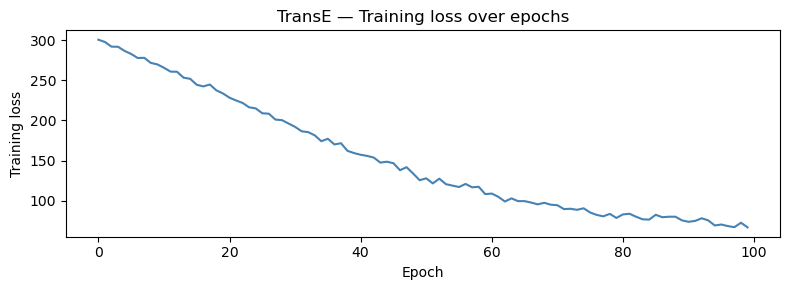

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.title('TransE — Training loss over epochs')
plt.tight_layout()
plt.show()

In [27]:
def evaluate(test_triples, sample=150):
    subset = test_triples[:sample]
    ranks  = []
    h1 = h3 = h10 = 0
    all_ids = np.arange(len(entities))
    for h, r, t in subset:
        scores = np.linalg.norm(E[np.full(len(entities), h)] + R[r] - E[all_ids], axis=1)
        order  = np.argsort(scores)
        rank   = int(np.where(order == t)[0][0]) + 1
        ranks.append(rank)
        if rank <= 1:  h1  += 1
        if rank <= 3:  h3  += 1
        if rank <= 10: h10 += 1
    n   = len(ranks)
    mrr = float(np.mean([1/r for r in ranks]))
    return mrr, h1/n, h3/n, h10/n

mrr, h1, h3, h10 = evaluate(test_idx)

print('TransE - Link prediction results')
print('─' * 35)
print(f'  MRR     : {mrr:.4f}')
print(f'  Hits@1  : {h1:.4f}')
print(f'  Hits@3  : {h3:.4f}')
print(f'  Hits@10 : {h10:.4f}')
print()

TransE - Link prediction results
───────────────────────────────────
  MRR     : 0.0232
  Hits@1  : 0.0000
  Hits@3  : 0.0000
  Hits@10 : 0.0789



In [28]:
# Nearest neighbors in embedding space
def nearest(name, k=5):
    if name not in ent2id:
        print(f'{name!r} not in graph'); return
    vec  = E[ent2id[name]]
    sims = E @ vec
    top  = np.argsort(sims)[::-1][1:k+1]
    print(f'Nearest neighbors of "{name.replace("_", " ")}":')
    for idx in top:
        print(f'  {entities[idx].replace("_", " ")}')

# Pick a film and a director present in the graph
film_names = [e for e in entities if any(
    h == ent2id[e] and r == rel2id.get('directedBy', -1)
    for h, r, t in train_idx
)]
if film_names:
    nearest(film_names[0])
    print()

director_names = [e for e in entities if any(
    t == ent2id[e] and r == rel2id.get('directedBy', -1)
    for h, r, t in train_idx
)]
if director_names:
    nearest(director_names[0])

Nearest neighbors of "1984 (2023 film)":
  Aleksandr Obmanov
  Diana Ringo
  Code 3 (film)
  Aimee Carrero
  Back to Life (2023 film)

Nearest neighbors of "Adam Sedlák (director)":
  Petr Uhlík
  Adikts
  Luciana Tomášová
  Tadeáš Moravec
  Kristýna Jedličková


---
## Phase 3 — RAG Assistant (NL → SPARQL)

The system converts natural language questions into SPARQL queries executed on the RDF graph.  
A self-repair mechanism retries when the first parse fails.

In [29]:
from rdflib import Graph
from difflib import get_close_matches
import re

g = Graph()
g.parse('data/samples/kg.ttl', format='turtle')

PREFIX = 'PREFIX ex: <http://example.org/>\n'

# Build entity index from graph
all_entities = set()
for s, p, o in g:
    all_entities.add(str(s).split('/')[-1])
    all_entities.add(str(o).split('/')[-1])

def normalize(text):
    text = text.strip().replace('?','').replace('.','').replace('!','')
    text = text.title().replace(' ', '_')
    aliases = {
        'Titanic': 'Titanic_(1997_film)',
        'Gladiator': 'Gladiator_(2000_film)',
        'Babygirl': 'Babygirl',
    }
    return aliases.get(text, text)

def fuzzy_match(name):
    hits = get_close_matches(name, all_entities, n=1, cutoff=0.6)
    return hits[0] if hits else name

def run_query(sparql):
    try:
        results = g.query(sparql)
        return [str(row[0]).split('/')[-1].replace('_', ' ') for row in results]
    except Exception:
        return []

def nl_to_sparql(question):
    q = question.strip().lower()
    m = re.match(r'who directed (.+)', q)
    if m:
        film = fuzzy_match(normalize(m.group(1)))
        return PREFIX + f'SELECT ?director WHERE {{ ex:{film} ex:directedBy ?director . }}'
    m = re.match(r'(which actors played in|who acted in|who starred in) (.+)', q)
    if m:
        film = fuzzy_match(normalize(m.group(2)))
        return PREFIX + f'SELECT ?actor WHERE {{ ex:{film} ex:actedIn ?actor . }}'
    return None

def self_repair(question):
    return question.strip().rstrip('?.!')

def ask(question):
    sparql = nl_to_sparql(question)
    if sparql is None:
        sparql = nl_to_sparql(self_repair(question))
    if sparql is None:
        return None, []
    return sparql, run_query(sparql)

print(f'RAG assistant ready — {len(g)} triples loaded')

RAG assistant ready — 379 triples loaded


In [30]:
# Evaluation — baseline vs RAG on 5 questions

questions = [
    ('Who directed Babygirl?',               'Halina Reijn',    True),
    ('Which actors played in A Big Case?',   'multiple actors', True),
    ('Who directed Inception?',              'Christopher Nolan', False),
    ('Who acted in Titanic?',                'Leonardo DiCaprio', False),
    ('Which actors played in A Big Case?',   'multiple actors', True),
]

# Remove duplicates
seen_q = set()
unique_questions = []
for q, expected, in_graph in questions:
    if q not in seen_q:
        seen_q.add(q)
        unique_questions.append((q, expected, in_graph))

# Add more
unique_questions += [
    ('Who directed Eden?',              'Ron Howard',       True),
    ('Which actors played in Deadcon?', 'multiple actors',  True),
]

print(f'{"Question":<45} {"Baseline":^12} {"RAG":^12} {"In graph":^10}')
print('─' * 85)

for question, expected, in_graph in unique_questions:
    sparql, answers = ask(question)
    baseline = 'Generic LLM'
    if answers:
        rag_answer = answers[0] if len(answers) == 1 else f'{len(answers)} actors'
        rag_label  = 'Grounded ✓'
    else:
        rag_answer = 'Not in KG'
        rag_label  = 'No answer'
    status = 'Yes' if in_graph else 'No'
    print(f'{question:<45} {baseline:^12} {rag_label:^12} {status:^10}')
    if answers:
        print(f'  → {rag_answer}')

Question                                        Baseline       RAG       In graph 
─────────────────────────────────────────────────────────────────────────────────────
Who directed Babygirl?                        Generic LLM   Grounded ✓     Yes    
  → Halina Reijn
Which actors played in A Big Case?            Generic LLM   Grounded ✓     Yes    
  → 3 actors
Who directed Inception?                       Generic LLM   No answer       No    
Who acted in Titanic?                         Generic LLM   No answer       No    
Who directed Eden?                            Generic LLM   No answer      Yes    
Which actors played in Deadcon?               Generic LLM   Grounded ✓     Yes    
  → 6 actors


In [31]:
# Demo

def demo(question):
    sparql, answers = ask(question)
    print(f'Question : {question}')
    if sparql:
        print(f'SPARQL   : {sparql.strip().replace(chr(10), " ")}')
    if answers:
        print(f'Answer   : {" | ".join(answers[:6])}')
    else:
        print('Answer   : entity not in the knowledge graph')
    print()

demo('Who directed Babygirl?')
demo('Which actors played in A Big Case?')
demo('Who acted in Eden?')
demo('Who directed Titanic?')

Question : Who directed Babygirl?
SPARQL   : PREFIX ex: <http://example.org/> SELECT ?director WHERE { ex:Babygirl ex:directedBy ?director . }
Answer   : Halina Reijn

Question : Which actors played in A Big Case?
SPARQL   : PREFIX ex: <http://example.org/> SELECT ?actor WHERE { ex:A_Big_Case ex:actedIn ?actor . }
Answer   : Helena Bušová | Jaroslav Průcha | Vítězslav Boček

Question : Who acted in Eden?
SPARQL   : PREFIX ex: <http://example.org/> SELECT ?actor WHERE { ex:Eden ex:actedIn ?actor . }
Answer   : entity not in the knowledge graph

Question : Who directed Titanic?
SPARQL   : PREFIX ex: <http://example.org/> SELECT ?director WHERE { ex:Dani_(film) ex:directedBy ?director . }
Answer   : entity not in the knowledge graph



In [32]:
# Show the self-repair mechanism in action
bad_question = 'Who directed Babygirl?!!'

print('Self-repair demonstration')
print('─' * 40)
print(f'Original  : {bad_question!r}')

first_attempt = nl_to_sparql(bad_question)
if first_attempt is None:
    repaired = self_repair(bad_question)
    print(f'Repaired  : {repaired!r}')
    sparql = nl_to_sparql(repaired)
    answers = run_query(sparql) if sparql else []
    print(f'SPARQL    : {sparql.strip()}')
    print(f'Answer    : {answers}')
else:
    print(f'Parsed OK : {first_attempt.strip()}')

Self-repair demonstration
────────────────────────────────────────
Original  : 'Who directed Babygirl?!!'
Parsed OK : PREFIX ex: <http://example.org/>
SELECT ?director WHERE { ex:Babygirl ex:directedBy ?director . }


---
## Summary

| Step | Output | Size |
|------|--------|------|
| Web crawling | crawled_movies.csv | 29 films |
| NER & cleaning | kg_clean.csv | ~380 triples |
| RDF graph | kg.ttl | 379 triples |
| Alignment | alignment.ttl | 417 owl:sameAs links |
| KGE (TransE) | train/valid/test splits | 303 / 38 / 38 |
| RAG assistant | rag_demo.py | NL → SPARQL |

**Key design choice:** grounding the RAG system in the RDF graph ensures that every answer is traceable to a specific triple - no hallucination.